In [1]:
# ============================================================
# Modeling Part 4 - Strategy Evaluation and Transaction Costs
# ============================================================
#
# Goal:
# 1. Load out-of-sample predictions from Modeling Part 3
# 2. Merge predictions with the original option bid/ask data
# 3. Recreate predicted-edge quintiles
# 4. Evaluate simple strategy interpretations:
#       - Buy all straddles
#       - Buy top predicted-edge quintile
#       - Avoid bottom predicted-edge quintile
#       - Theoretical long Q5 / short Q1 spread
# 5. Add simple transaction-cost-aware versions using bid/ask prices
# 6. Check year-by-year stability
#
# Important:
# This notebook does NOT prove a directly tradable strategy yet.
# It evaluates whether the model's ranking is economically meaningful.

import os
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

con = duckdb.connect()

PROCESSED_DIR = r"data\processed"

# Inputs
oos_predictions_file = os.path.join(PROCESSED_DIR, "modeling_part3_oos_predictions.parquet")
simple_clean_loose_file = os.path.join(PROCESSED_DIR, "earnings_model_simple_clean_loose.parquet")
simple_clean_strict_file = os.path.join(PROCESSED_DIR, "earnings_model_simple_clean_strict.parquet")

# Outputs
strategy_results_file = os.path.join(PROCESSED_DIR, "modeling_part4_strategy_results.parquet")
yearly_strategy_results_file = os.path.join(PROCESSED_DIR, "modeling_part4_yearly_strategy_results.parquet")
strategy_results_csv = os.path.join(PROCESSED_DIR, "modeling_part4_strategy_results.csv")
yearly_strategy_results_csv = os.path.join(PROCESSED_DIR, "modeling_part4_yearly_strategy_results.csv")

print("Input files:")
print(oos_predictions_file)
print(simple_clean_loose_file)
print(simple_clean_strict_file)

print("\nOutput files:")
print(strategy_results_file)
print(yearly_strategy_results_file)

Input files:
data\processed\modeling_part3_oos_predictions.parquet
data\processed\earnings_model_simple_clean_loose.parquet
data\processed\earnings_model_simple_clean_strict.parquet

Output files:
data\processed\modeling_part4_strategy_results.parquet
data\processed\modeling_part4_yearly_strategy_results.parquet


In [2]:
# Helper function to print SQL outputs neatly

def show(title, query, n=30):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)
    
    df = con.execute(query).df()
    
    if len(df) > n:
        print(df.head(n).to_string(index=False))
        print(f"\n[showing first {n} rows out of {len(df)}]")
    else:
        print(df.to_string(index=False))
    
    return df


# Helper function to create quintiles

def add_quintiles(df, score_col, group_cols=None, n_quintiles=5, ascending=True):
    """
    Adds quintiles based on score_col.
    
    If group_cols is None:
        quintiles are created across the full dataframe.
    
    If group_cols is provided:
        quintiles are created within each group, e.g. within each test_year.
    
    ascending=True:
        Q1 = lowest score
        Q5 = highest score
    """
    df = df.copy()
    
    if group_cols is None:
        df["quintile"] = pd.qcut(
            df[score_col].rank(method="first", ascending=ascending),
            q=n_quintiles,
            labels=False
        ) + 1
    else:
        df["quintile"] = (
            df
            .groupby(group_cols, group_keys=False)
            .apply(
                lambda g: pd.qcut(
                    g[score_col].rank(method="first", ascending=ascending),
                    q=n_quintiles,
                    labels=False
                ) + 1
            )
        )
    
    df["quintile"] = df["quintile"].astype(int)
    return df


# Helper function to summarize a strategy group

def summarize_group(df, label, model_col="model"):
    """
    Summarizes average edge/proxy returns for a selected group of rows.
    """
    return pd.DataFrame({
        "strategy": [label],
        "n_events": [len(df)],
        "n_tickers": [df["tic"].nunique()],
        "avg_mid_edge": [df["mid_edge"].mean()],
        "median_mid_edge": [df["mid_edge"].median()],
        "pct_positive_mid_edge": [(df["mid_edge"] > 0).mean()],
        "avg_long_ask_edge": [df["long_ask_edge"].mean()],
        "median_long_ask_edge": [df["long_ask_edge"].median()],
        "pct_positive_long_ask_edge": [(df["long_ask_edge"] > 0).mean()],
        "avg_short_bid_edge": [df["short_bid_edge"].mean()],
        "median_short_bid_edge": [df["short_bid_edge"].median()],
        "pct_positive_short_bid_edge": [(df["short_bid_edge"] > 0).mean()],
        "avg_implied_move_mid": [df["implied_move_simple"].mean()],
        "avg_realized_move": [df["realized_move_open_to_prevclose"].mean()],
    })

In [3]:
# Make sure required files exist before continuing.

required_files = [
    oos_predictions_file,
    simple_clean_loose_file,
    simple_clean_strict_file
]

for file in required_files:
    if not os.path.exists(file):
        raise FileNotFoundError(f"Missing file: {file}")

print("All required input files found.")

All required input files found.


In [4]:
# Load out-of-sample predictions from Modeling Part 3.
#
# This file contains predictions only for test years:
#     2021, 2022, 2023, 2024
#
# It contains:
#     predicted_edge
#     actual edge
#     model name
#     features used

con.execute(f"""
CREATE OR REPLACE TEMP TABLE oos_predictions AS
SELECT *
FROM read_parquet('{oos_predictions_file}')
""")

# Load the clean simple dataset.
# This contains option bid/ask prices needed for transaction-cost analysis.

con.execute(f"""
CREATE OR REPLACE TEMP TABLE simple_loose AS
SELECT *
FROM read_parquet('{simple_clean_loose_file}')
""")

con.execute(f"""
CREATE OR REPLACE TEMP TABLE simple_strict AS
SELECT *
FROM read_parquet('{simple_clean_strict_file}')
""")

show(
    "Input row counts",
    """
    SELECT 'oos_predictions' AS dataset, COUNT(*) AS n_rows FROM oos_predictions
    UNION ALL
    SELECT 'simple_loose' AS dataset, COUNT(*) AS n_rows FROM simple_loose
    UNION ALL
    SELECT 'simple_strict' AS dataset, COUNT(*) AS n_rows FROM simple_strict
    """
)

show(
    "Prediction sample",
    """
    SELECT *
    FROM oos_predictions
    LIMIT 5
    """
)


Input row counts
        dataset  n_rows
oos_predictions   11032
   simple_loose    9022
  simple_strict    7412

Prediction sample
tic        rdq  earnings_year  test_year             model  simple_straddle_edge_open  realized_move_open_to_prevclose  predicted_edge  implied_move_simple  total_spread_pct  log_total_open_interest  log_total_volume  log_stock_price  earnings_month
 LW 2021-01-07           2021       2021 linear_regression                  -0.049197                         0.017356       -0.024945             0.066554          0.154262                 7.021084          4.634729         4.338989               1
 MU 2021-01-07           2021       2021 linear_regression                   0.003437                         0.070419       -0.016863             0.066982          0.017384                 8.165648          8.351847         4.345233               1
STZ 2021-01-07           2021       2021 linear_regression                  -0.016673                         0.02869

,tic,rdq,earnings_year,test_year,model,simple_straddle_edge_open,realized_move_open_to_prevclose,predicted_edge,implied_move_simple,total_spread_pct,log_total_open_interest,log_total_volume,log_stock_price,earnings_month
0,LW,2021-01-07,2021,2021,linear_regression,-0.049197,0.017356,-0.024945,0.066554,0.154262,7.021084,4.634729,4.338989,1
1,MU,2021-01-07,2021,2021,linear_regression,0.003437,0.070419,-0.016863,0.066982,0.017384,8.165648,8.351847,4.345233,1
2,STZ,2021-01-07,2021,2021,linear_regression,-0.016673,0.028697,-0.009796,0.045369,0.090650,4.787492,5.010635,5.410395,1
3,CCL,2021-01-11,2021,2021,linear_regression,-0.066683,0.020518,-0.025476,0.087201,0.017033,8.828055,8.609408,3.018960,1
4,BLK,2021-01-14,2021,2021,linear_regression,0.022789,0.048182,-0.001416,0.025393,0.112700,5.634790,6.424869,6.658973,1


In [5]:
# Merge predictions with the clean straddle data to recover bid/ask fields.
#
# We need:
#     after_call_bid
#     after_call_ask
#     after_put_bid
#     after_put_ask
#
# because transaction costs depend on whether we buy at ask or sell at bid.

con.execute("""
CREATE OR REPLACE TEMP TABLE pred_with_quotes AS
SELECT
    p.*,

    s.after_call_bid,
    s.after_call_ask,
    s.after_put_bid,
    s.after_put_ask,

    s.after_call_mid,
    s.after_put_mid,
    s.after_straddle_mid,

    s.after_call_spread_pct,
    s.after_put_spread_pct,

    s.after_call_oi,
    s.after_put_oi,
    s.after_call_vol,
    s.after_put_vol,

    s.om_close,
    s.strike,
    s.after_exdate

FROM oos_predictions p
LEFT JOIN simple_loose s
  ON p.tic = s.tic
 AND p.rdq = s.rdq
 AND p.earnings_year = s.earnings_year
""")

show(
    "Merged prediction + quote row count",
    """
    SELECT
        COUNT(*) AS n_rows,
        SUM(CASE WHEN after_call_bid IS NULL THEN 1 ELSE 0 END) AS missing_call_bid,
        SUM(CASE WHEN after_put_bid IS NULL THEN 1 ELSE 0 END) AS missing_put_bid,
        SUM(CASE WHEN om_close IS NULL THEN 1 ELSE 0 END) AS missing_stock_price
    FROM pred_with_quotes
    """
)

show(
    "Sample merged rows",
    """
    SELECT
        model,
        tic,
        rdq,
        earnings_year,
        predicted_edge,
        simple_straddle_edge_open,
        implied_move_simple,
        realized_move_open_to_prevclose,
        after_call_bid,
        after_call_ask,
        after_put_bid,
        after_put_ask,
        om_close
    FROM pred_with_quotes
    LIMIT 10
    """
)


Merged prediction + quote row count
 n_rows  missing_call_bid  missing_put_bid  missing_stock_price
  11032               0.0              0.0                  0.0

Sample merged rows
            model tic        rdq  earnings_year  predicted_edge  simple_straddle_edge_open  implied_move_simple  realized_move_open_to_prevclose  after_call_bid  after_call_ask  after_put_bid  after_put_ask  om_close
linear_regression  LW 2021-01-07           2021       -0.024945                  -0.049197             0.066554                         0.017356            3.10            3.40           1.65           2.05     76.63
linear_regression  MU 2021-01-07           2021       -0.016863                   0.003437             0.066982                         0.070419            2.63            2.68           2.49           2.53     77.11
linear_regression STZ 2021-01-07           2021       -0.009796                  -0.016673             0.045369                         0.028697            5.90    

,model,tic,rdq,earnings_year,predicted_edge,simple_straddle_edge_open,implied_move_simple,realized_move_open_to_prevclose,after_call_bid,after_call_ask,after_put_bid,after_put_ask,om_close
0,linear_regression,LW,2021-01-07,2021,-0.024945,-0.049197,0.066554,0.017356,3.10,3.40,1.65,2.05,76.63
1,linear_regression,MU,2021-01-07,2021,-0.016863,0.003437,0.066982,0.070419,2.63,2.68,2.49,2.53,77.11
2,linear_regression,STZ,2021-01-07,2021,-0.009796,-0.016673,0.045369,0.028697,5.90,6.40,3.80,4.20,223.72
3,linear_regression,CCL,2021-01-11,2021,-0.025476,-0.066683,0.087201,0.020518,0.85,0.87,0.92,0.93,20.47
4,linear_regression,BLK,2021-01-14,2021,-0.001416,0.022789,0.025393,0.048182,11.00,12.20,7.70,8.70,779.75
5,linear_regression,DAL,2021-01-14,2021,-0.009108,-0.012485,0.042645,0.030161,1.13,1.15,0.58,0.59,40.45
6,linear_regression,C,2021-01-15,2021,-0.011216,-0.000145,0.055354,0.055209,1.95,2.01,1.80,1.88,69.01
7,linear_regression,JPM,2021-01-15,2021,-0.006162,-0.031629,0.040908,0.009280,3.20,3.35,2.45,2.55,141.17
8,linear_regression,WFC,2021-01-15,2021,-0.016271,0.002446,0.064892,0.067338,1.25,1.28,0.98,1.00,34.75
9,linear_regression,BAC,2021-01-19,2021,-0.006005,-0.036958,0.044532,0.007573,0.71,0.73,0.74,0.76,33.01


In [6]:
# Create different edge measures.
#
# 1. Midpoint edge:
#       uses midpoint straddle price
#       this is what we used earlier
#
#       mid_edge = realized move - midpoint implied move
#
# 2. Long at ask edge:
#       if we BUY the straddle, we likely pay ask prices
#
#       ask_straddle = call ask + put ask
#       long_ask_edge = realized move - ask implied move
#
#       This is more conservative than midpoint edge.
#
# 3. Short at bid edge:
#       if we SELL the straddle, we likely receive bid prices
#
#       bid_straddle = call bid + put bid
#       short_bid_edge = bid implied move - realized move
#
#       Positive means shorting the straddle would have been profitable
#       in this simplified move-based proxy.

con.execute("""
CREATE OR REPLACE TEMP TABLE strategy_base AS
SELECT
    *,

    -- Midpoint straddle cost
    after_straddle_mid / om_close AS mid_implied_move,

    -- Ask straddle cost if buying
    (after_call_ask + after_put_ask) / om_close AS ask_implied_move,

    -- Bid straddle sale price if selling
    (after_call_bid + after_put_bid) / om_close AS bid_implied_move,

    -- Midpoint edge for long straddle
    realized_move_open_to_prevclose - (after_straddle_mid / om_close) AS mid_edge,

    -- Long straddle edge after paying ask
    realized_move_open_to_prevclose - ((after_call_ask + after_put_ask) / om_close) AS long_ask_edge,

    -- Short straddle edge after selling at bid
    ((after_call_bid + after_put_bid) / om_close) - realized_move_open_to_prevclose AS short_bid_edge,

    -- Full straddle spread as percentage of stock price
    ((after_call_ask + after_put_ask) - (after_call_bid + after_put_bid)) / om_close AS straddle_spread_pct_of_stock,

    -- Full straddle spread relative to midpoint straddle
    CASE
        WHEN after_straddle_mid IS NOT NULL AND after_straddle_mid > 0
        THEN ((after_call_ask + after_put_ask) - (after_call_bid + after_put_bid)) / after_straddle_mid
        ELSE NULL
    END AS straddle_spread_pct_of_mid

FROM pred_with_quotes
WHERE om_close IS NOT NULL
  AND om_close > 0
  AND after_call_bid IS NOT NULL
  AND after_call_ask IS NOT NULL
  AND after_put_bid IS NOT NULL
  AND after_put_ask IS NOT NULL
""")

show(
    "Strategy base summary",
    """
    SELECT
        COUNT(*) AS n_rows,
        AVG(mid_implied_move) AS avg_mid_implied_move,
        AVG(ask_implied_move) AS avg_ask_implied_move,
        AVG(bid_implied_move) AS avg_bid_implied_move,
        AVG(realized_move_open_to_prevclose) AS avg_realized_move,
        AVG(mid_edge) AS avg_mid_edge,
        AVG(long_ask_edge) AS avg_long_ask_edge,
        AVG(short_bid_edge) AS avg_short_bid_edge,
        AVG(straddle_spread_pct_of_stock) AS avg_straddle_spread_pct_of_stock,
        AVG(straddle_spread_pct_of_mid) AS avg_straddle_spread_pct_of_mid
    FROM strategy_base
    """
)


Strategy base summary
 n_rows  avg_mid_implied_move  avg_ask_implied_move  avg_bid_implied_move  avg_realized_move  avg_mid_edge  avg_long_ask_edge  avg_short_bid_edge  avg_straddle_spread_pct_of_stock  avg_straddle_spread_pct_of_mid
  11032              0.057863              0.060818              0.054909           0.044263       -0.0136          -0.016555            0.010646                          0.005908                        0.105944


,n_rows,avg_mid_implied_move,avg_ask_implied_move,avg_bid_implied_move,avg_realized_move,avg_mid_edge,avg_long_ask_edge,avg_short_bid_edge,avg_straddle_spread_pct_of_stock,avg_straddle_spread_pct_of_mid
0,11032,0.057863,0.060818,0.054909,0.044263,-0.0136,-0.016555,0.010646,0.005908,0.105944


In [10]:
# Load strategy_base into pandas for easier strategy grouping.
#
# IMPORTANT:
# We recreate strategy_df fresh from DuckDB.
# This fixes any index/column issues caused by previous failed groupby/apply attempts.

strategy_df = con.execute("""
SELECT *
FROM strategy_base
ORDER BY model, test_year, rdq, tic
""").df()

# Make sure model and test_year are normal columns, not index levels
strategy_df = strategy_df.reset_index(drop=True)

print("Strategy dataframe shape:", strategy_df.shape)

print("\nColumns:")
print(strategy_df.columns.tolist())

display(strategy_df.head())

Strategy dataframe shape: (11032, 38)

Columns:
['tic', 'rdq', 'earnings_year', 'test_year', 'model', 'simple_straddle_edge_open', 'realized_move_open_to_prevclose', 'predicted_edge', 'implied_move_simple', 'total_spread_pct', 'log_total_open_interest', 'log_total_volume', 'log_stock_price', 'earnings_month', 'after_call_bid', 'after_call_ask', 'after_put_bid', 'after_put_ask', 'after_call_mid', 'after_put_mid', 'after_straddle_mid', 'after_call_spread_pct', 'after_put_spread_pct', 'after_call_oi', 'after_put_oi', 'after_call_vol', 'after_put_vol', 'om_close', 'strike', 'after_exdate', 'mid_implied_move', 'ask_implied_move', 'bid_implied_move', 'mid_edge', 'long_ask_edge', 'short_bid_edge', 'straddle_spread_pct_of_stock', 'straddle_spread_pct_of_mid']


,tic,rdq,earnings_year,test_year,model,simple_straddle_edge_open,realized_move_open_to_prevclose,predicted_edge,implied_move_simple,total_spread_pct,...,strike,after_exdate,mid_implied_move,ask_implied_move,bid_implied_move,mid_edge,long_ask_edge,short_bid_edge,straddle_spread_pct_of_stock,straddle_spread_pct_of_mid
0,LW,2021-01-07,2021,2021,linear_regression,-0.049197,0.017356,-0.024945,0.066554,0.154262,...,75.0,2021-01-15,0.066554,0.071121,0.061986,-0.049197,-0.053765,0.044630,0.009135,0.137255
1,MU,2021-01-07,2021,2021,linear_regression,0.003437,0.070419,-0.016863,0.066982,0.017384,...,77.0,2021-01-08,0.066982,0.067566,0.066399,0.003437,0.002853,-0.004020,0.001167,0.017425
2,STZ,2021-01-07,2021,2021,linear_regression,-0.016673,0.028697,-0.009796,0.045369,0.090650,...,222.5,2021-01-08,0.045369,0.047381,0.043358,-0.016673,-0.018684,0.014661,0.004023,0.088670
3,CCL,2021-01-11,2021,2021,linear_regression,-0.066683,0.020518,-0.025476,0.087201,0.017033,...,20.5,2021-01-15,0.087201,0.087934,0.086468,-0.066683,-0.067416,0.065950,0.001466,0.016807
4,BLK,2021-01-14,2021,2021,linear_regression,0.022789,0.048182,-0.001416,0.025393,0.112700,...,780.0,2021-01-15,0.025393,0.026803,0.023982,0.022789,0.021379,-0.024200,0.002821,0.111111


In [11]:
# Add predicted-edge quintiles.
#
# We create quintiles within each model and each test year.
#
# Q1 = lowest predicted edge = predicted worst straddles
# Q5 = highest predicted edge = predicted best straddles

quintile_parts = []

for (model_name, test_year), group in strategy_df.groupby(["model", "test_year"]):
    g = group.copy()
    
    # Rank predicted edge within this model/year group
    g["quintile"] = pd.qcut(
        g["predicted_edge"].rank(method="first"),
        q=5,
        labels=False
    ) + 1
    
    g["quintile"] = g["quintile"].astype(int)
    
    quintile_parts.append(g)

strategy_df = pd.concat(quintile_parts, ignore_index=True)

display(
    strategy_df[
        [
            "model",
            "test_year",
            "tic",
            "rdq",
            "predicted_edge",
            "quintile",
            "mid_edge",
            "long_ask_edge",
            "short_bid_edge"
        ]
    ].head(20)
)

print("Quintile counts:")
display(
    strategy_df
    .groupby(["model", "test_year", "quintile"])
    .size()
    .reset_index(name="n_events")
    .head(30)
)

,model,test_year,tic,rdq,predicted_edge,quintile,mid_edge,long_ask_edge,short_bid_edge
0,linear_regression,2021,LW,2021-01-07,-0.024945,1,-0.049197,-0.053765,0.044630
1,linear_regression,2021,MU,2021-01-07,-0.016863,2,0.003437,0.002853,-0.004020
2,linear_regression,2021,STZ,2021-01-07,-0.009796,4,-0.016673,-0.018684,0.014661
3,linear_regression,2021,CCL,2021-01-11,-0.025476,1,-0.066683,-0.067416,0.065950
4,linear_regression,2021,BLK,2021-01-14,-0.001416,5,0.022789,0.021379,-0.024200
5,linear_regression,2021,DAL,2021-01-14,-0.009108,4,-0.012485,-0.012855,0.012114
6,linear_regression,2021,C,2021-01-15,-0.011216,3,-0.000145,-0.001159,-0.000869
7,linear_regression,2021,JPM,2021-01-15,-0.006162,4,-0.031629,-0.032514,0.030743
8,linear_regression,2021,WFC,2021-01-15,-0.016271,2,0.002446,0.001727,-0.003165
9,linear_regression,2021,BAC,2021-01-19,-0.006005,4,-0.036958,-0.037564,0.036353


Quintile counts:


,model,test_year,quintile,n_events
0,linear_regression,2021,1,251
1,linear_regression,2021,2,250
2,linear_regression,2021,3,251
3,linear_regression,2021,4,250
4,linear_regression,2021,5,251
5,linear_regression,2022,1,262
6,linear_regression,2022,2,261
7,linear_regression,2022,3,262
8,linear_regression,2022,4,261
9,linear_regression,2022,5,262


In [12]:
# Summarize performance by predicted-edge quintile.
#
# For predicted_edge:
#     Q1 = model thinks these are worst
#     Q5 = model thinks these are best
#
# We want:
#     Q5 mid_edge > Q1 mid_edge
#
# For long-only straddle buying:
#     long_ask_edge is more realistic than mid_edge
#
# For shorting expensive straddles:
#     short_bid_edge for Q1 is relevant

quintile_perf = (
    strategy_df
    .groupby(["model", "quintile"])
    .agg(
        n_events=("tic", "size"),
        n_tickers=("tic", "nunique"),
        avg_predicted_edge=("predicted_edge", "mean"),
        avg_mid_edge=("mid_edge", "mean"),
        median_mid_edge=("mid_edge", "median"),
        pct_positive_mid_edge=("mid_edge", lambda x: np.mean(x > 0)),
        avg_long_ask_edge=("long_ask_edge", "mean"),
        median_long_ask_edge=("long_ask_edge", "median"),
        pct_positive_long_ask_edge=("long_ask_edge", lambda x: np.mean(x > 0)),
        avg_short_bid_edge=("short_bid_edge", "mean"),
        median_short_bid_edge=("short_bid_edge", "median"),
        pct_positive_short_bid_edge=("short_bid_edge", lambda x: np.mean(x > 0)),
        avg_implied_move=("implied_move_simple", "mean"),
        avg_realized_move=("realized_move_open_to_prevclose", "mean"),
        avg_spread_cost=("straddle_spread_pct_of_stock", "mean")
    )
    .reset_index()
)

display(quintile_perf)

,model,quintile,n_events,n_tickers,avg_predicted_edge,avg_mid_edge,median_mid_edge,pct_positive_mid_edge,avg_long_ask_edge,median_long_ask_edge,pct_positive_long_ask_edge,avg_short_bid_edge,median_short_bid_edge,pct_positive_short_bid_edge,avg_implied_move,avg_realized_move,avg_spread_cost
0,linear_regression,1,1105,238,-0.033012,-0.024319,-0.036882,0.250679,-0.029692,-0.043238,0.226244,0.018946,0.030231,0.718552,0.090395,0.066076,0.010746
1,linear_regression,2,1102,322,-0.020642,-0.017221,-0.026569,0.251361,-0.020759,-0.030455,0.225953,0.013683,0.021484,0.724138,0.063867,0.046646,0.007076
2,linear_regression,3,1103,348,-0.014961,-0.013956,-0.021510,0.270172,-0.016627,-0.024723,0.246600,0.011285,0.018387,0.700816,0.054073,0.040117,0.005342
3,linear_regression,4,1102,289,-0.009867,-0.007686,-0.014221,0.323956,-0.009646,-0.016404,0.302178,0.005726,0.012361,0.651543,0.045368,0.037681,0.003920
4,linear_regression,5,1104,188,-0.003820,-0.004806,-0.009156,0.357790,-0.006032,-0.010288,0.336957,0.003581,0.008104,0.628623,0.035569,0.030763,0.002451
5,ridge_regression,1,1105,238,-0.033008,-0.024319,-0.036882,0.250679,-0.029692,-0.043238,0.226244,0.018946,0.030231,0.718552,0.090395,0.066076,0.010746
6,ridge_regression,2,1102,322,-0.020640,-0.017221,-0.026569,0.251361,-0.020759,-0.030455,0.225953,0.013683,0.021484,0.724138,0.063867,0.046646,0.007076
7,ridge_regression,3,1103,348,-0.014961,-0.013956,-0.021510,0.270172,-0.016627,-0.024723,0.246600,0.011285,0.018387,0.700816,0.054073,0.040117,0.005342
8,ridge_regression,4,1102,289,-0.009868,-0.007686,-0.014221,0.323956,-0.009646,-0.016404,0.302178,0.005726,0.012361,0.651543,0.045368,0.037681,0.003920
9,ridge_regression,5,1104,188,-0.003822,-0.004806,-0.009156,0.357790,-0.006032,-0.010288,0.336957,0.003581,0.008104,0.628623,0.035569,0.030763,0.002451


In [13]:
# Create simple strategy interpretation tables.
#
# For each model:
#
# 1. Buy all:
#       average result of buying every straddle in the test sample
#
# 2. Buy Q5:
#       buy only highest predicted-edge straddles
#
# 3. Avoid Q1:
#       shows what you avoid by not buying the predicted-worst group
#
# 4. Theoretical long Q5 / short Q1 spread:
#       midpoint version:
#           Q5 mid edge - Q1 mid edge
#
#       transaction-cost-aware version:
#           long Q5 at ask + short Q1 at bid
#
#       For long Q5:
#           use long_ask_edge
#
#       For short Q1:
#           use short_bid_edge
#
#       Combined spread proxy:
#           avg_long_ask_edge_Q5 + avg_short_bid_edge_Q1

strategy_rows = []

for model_name in sorted(strategy_df["model"].unique()):
    temp = strategy_df[strategy_df["model"] == model_name].copy()
    
    q1 = temp[temp["quintile"] == 1].copy()
    q5 = temp[temp["quintile"] == 5].copy()
    
    # Buy all, midpoint
    strategy_rows.append({
        "model": model_name,
        "strategy": "Buy all straddles - midpoint",
        "n_events": len(temp),
        "avg_edge": temp["mid_edge"].mean(),
        "median_edge": temp["mid_edge"].median(),
        "pct_positive": (temp["mid_edge"] > 0).mean()
    })
    
    # Buy all, at ask
    strategy_rows.append({
        "model": model_name,
        "strategy": "Buy all straddles - at ask",
        "n_events": len(temp),
        "avg_edge": temp["long_ask_edge"].mean(),
        "median_edge": temp["long_ask_edge"].median(),
        "pct_positive": (temp["long_ask_edge"] > 0).mean()
    })
    
    # Buy Q5, midpoint
    strategy_rows.append({
        "model": model_name,
        "strategy": "Buy Q5 predicted-best - midpoint",
        "n_events": len(q5),
        "avg_edge": q5["mid_edge"].mean(),
        "median_edge": q5["mid_edge"].median(),
        "pct_positive": (q5["mid_edge"] > 0).mean()
    })
    
    # Buy Q5, at ask
    strategy_rows.append({
        "model": model_name,
        "strategy": "Buy Q5 predicted-best - at ask",
        "n_events": len(q5),
        "avg_edge": q5["long_ask_edge"].mean(),
        "median_edge": q5["long_ask_edge"].median(),
        "pct_positive": (q5["long_ask_edge"] > 0).mean()
    })
    
    # Buy Q1, midpoint, shown as bad group
    strategy_rows.append({
        "model": model_name,
        "strategy": "Buy Q1 predicted-worst - midpoint",
        "n_events": len(q1),
        "avg_edge": q1["mid_edge"].mean(),
        "median_edge": q1["mid_edge"].median(),
        "pct_positive": (q1["mid_edge"] > 0).mean()
    })
    
    # Short Q1, at bid
    strategy_rows.append({
        "model": model_name,
        "strategy": "Short Q1 predicted-worst - at bid",
        "n_events": len(q1),
        "avg_edge": q1["short_bid_edge"].mean(),
        "median_edge": q1["short_bid_edge"].median(),
        "pct_positive": (q1["short_bid_edge"] > 0).mean()
    })
    
    # Long Q5 / Short Q1 midpoint spread
    strategy_rows.append({
        "model": model_name,
        "strategy": "Long Q5 / Short Q1 - midpoint spread",
        "n_events": min(len(q5), len(q1)),
        "avg_edge": q5["mid_edge"].mean() - q1["mid_edge"].mean(),
        "median_edge": q5["mid_edge"].median() - q1["mid_edge"].median(),
        "pct_positive": np.nan
    })
    
    # Long Q5 ask + Short Q1 bid
    strategy_rows.append({
        "model": model_name,
        "strategy": "Long Q5 at ask / Short Q1 at bid",
        "n_events": min(len(q5), len(q1)),
        "avg_edge": q5["long_ask_edge"].mean() + q1["short_bid_edge"].mean(),
        "median_edge": q5["long_ask_edge"].median() + q1["short_bid_edge"].median(),
        "pct_positive": np.nan
    })

strategy_summary = pd.DataFrame(strategy_rows)

display(strategy_summary)

,model,strategy,n_events,avg_edge,median_edge,pct_positive
0,linear_regression,Buy all straddles - midpoint,5516,-0.013600,-0.018729,0.290790
1,linear_regression,Buy all straddles - at ask,5516,-0.016555,-0.021338,0.267585
2,linear_regression,Buy Q5 predicted-best - midpoint,1104,-0.004806,-0.009156,0.357790
3,linear_regression,Buy Q5 predicted-best - at ask,1104,-0.006032,-0.010288,0.336957
4,linear_regression,Buy Q1 predicted-worst - midpoint,1105,-0.024319,-0.036882,0.250679
5,linear_regression,Short Q1 predicted-worst - at bid,1105,0.018946,0.030231,0.718552
6,linear_regression,Long Q5 / Short Q1 - midpoint spread,1104,0.019513,0.027726,NaN
7,linear_regression,Long Q5 at ask / Short Q1 at bid,1104,0.012914,0.019943,NaN
8,ridge_regression,Buy all straddles - midpoint,5516,-0.013600,-0.018729,0.290790
9,ridge_regression,Buy all straddles - at ask,5516,-0.016555,-0.021338,0.267585


In [14]:
# Check strategy performance by year.
#
# This tells us whether the result is stable or driven by one year.

yearly_quintile_perf = (
    strategy_df
    .groupby(["model", "test_year", "quintile"])
    .agg(
        n_events=("tic", "size"),
        avg_predicted_edge=("predicted_edge", "mean"),
        avg_mid_edge=("mid_edge", "mean"),
        avg_long_ask_edge=("long_ask_edge", "mean"),
        avg_short_bid_edge=("short_bid_edge", "mean"),
        pct_positive_mid_edge=("mid_edge", lambda x: np.mean(x > 0)),
        avg_implied_move=("implied_move_simple", "mean"),
        avg_realized_move=("realized_move_open_to_prevclose", "mean"),
        avg_spread_cost=("straddle_spread_pct_of_stock", "mean")
    )
    .reset_index()
)

display(yearly_quintile_perf.head(30))

,model,test_year,quintile,n_events,avg_predicted_edge,avg_mid_edge,avg_long_ask_edge,avg_short_bid_edge,pct_positive_mid_edge,avg_implied_move,avg_realized_move,avg_spread_cost
0,linear_regression,2021,1,251,-0.028940,-0.028721,-0.035310,0.022132,0.187251,0.076757,0.048035,0.013178
1,linear_regression,2021,2,250,-0.018684,-0.018199,-0.022304,0.014094,0.216000,0.057748,0.039549,0.008210
2,linear_regression,2021,3,251,-0.013096,-0.018284,-0.021080,0.015489,0.179283,0.049551,0.031267,0.005591
3,linear_regression,2021,4,250,-0.008108,-0.010730,-0.012709,0.008751,0.272000,0.041245,0.030515,0.003958
4,linear_regression,2021,5,251,-0.002310,-0.004883,-0.006019,0.003747,0.322709,0.031068,0.026185,0.002272
5,linear_regression,2022,1,262,-0.038468,-0.036556,-0.043525,0.029588,0.202290,0.102245,0.065689,0.013937
6,linear_regression,2022,2,261,-0.023753,-0.024279,-0.028614,0.019945,0.210728,0.070232,0.045952,0.008669
7,linear_regression,2022,3,262,-0.017723,-0.016446,-0.019950,0.012943,0.244275,0.060007,0.043560,0.007008
8,linear_regression,2022,4,261,-0.012341,-0.009389,-0.011901,0.006877,0.310345,0.049937,0.040549,0.005024
9,linear_regression,2022,5,262,-0.005931,-0.006309,-0.007981,0.004637,0.328244,0.038367,0.032058,0.003344


In [15]:
# Create year-by-year Q5 minus Q1 spread.
#
# Midpoint spread:
#     Q5 mid edge - Q1 mid edge
#
# Transaction-cost-aware spread:
#     Long Q5 at ask + Short Q1 at bid

yearly_spread_rows = []

for model_name in sorted(strategy_df["model"].unique()):
    model_data = strategy_df[strategy_df["model"] == model_name].copy()
    
    for year in sorted(model_data["test_year"].unique()):
        temp = model_data[model_data["test_year"] == year].copy()
        
        q1 = temp[temp["quintile"] == 1]
        q5 = temp[temp["quintile"] == 5]
        
        yearly_spread_rows.append({
            "model": model_name,
            "test_year": year,
            "q1_mid_edge": q1["mid_edge"].mean(),
            "q5_mid_edge": q5["mid_edge"].mean(),
            "q5_minus_q1_mid_edge": q5["mid_edge"].mean() - q1["mid_edge"].mean(),
            
            "q5_long_ask_edge": q5["long_ask_edge"].mean(),
            "q1_short_bid_edge": q1["short_bid_edge"].mean(),
            "long_q5_ask_short_q1_bid_edge": q5["long_ask_edge"].mean() + q1["short_bid_edge"].mean(),
            
            "n_q1": len(q1),
            "n_q5": len(q5)
        })

yearly_strategy_spreads = pd.DataFrame(yearly_spread_rows)

display(yearly_strategy_spreads)

,model,test_year,q1_mid_edge,q5_mid_edge,q5_minus_q1_mid_edge,q5_long_ask_edge,q1_short_bid_edge,long_q5_ask_short_q1_bid_edge,n_q1,n_q5
0,linear_regression,2021,-0.028721,-0.004883,0.023838,-0.006019,0.022132,0.016113,251,251
1,linear_regression,2022,-0.036556,-0.006309,0.030247,-0.007981,0.029588,0.021607,262,262
2,linear_regression,2023,-0.015927,-0.003015,0.012913,-0.004018,0.011885,0.007867,286,286
3,linear_regression,2024,-0.018073,-0.005132,0.012942,-0.006255,0.013820,0.007565,306,305
4,ridge_regression,2021,-0.028721,-0.004883,0.023838,-0.006019,0.022132,0.016113,251,251
5,ridge_regression,2022,-0.036556,-0.006309,0.030247,-0.007981,0.029588,0.021607,262,262
6,ridge_regression,2023,-0.015927,-0.003015,0.012913,-0.004018,0.011885,0.007867,286,286
7,ridge_regression,2024,-0.018073,-0.005132,0.012942,-0.006255,0.013820,0.007565,306,305


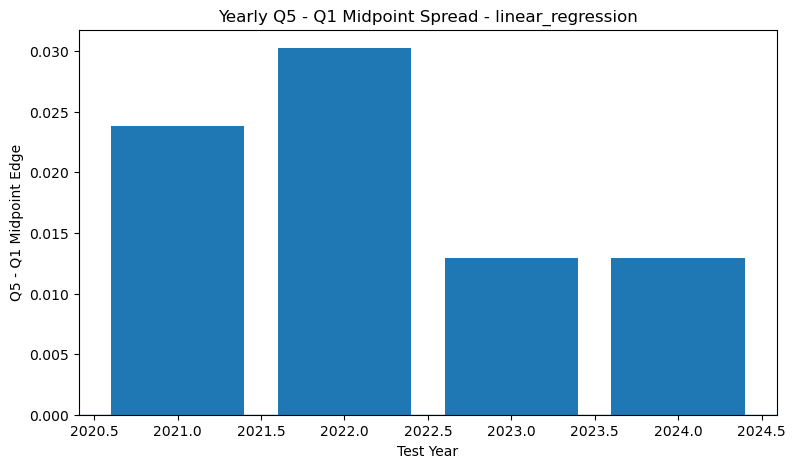

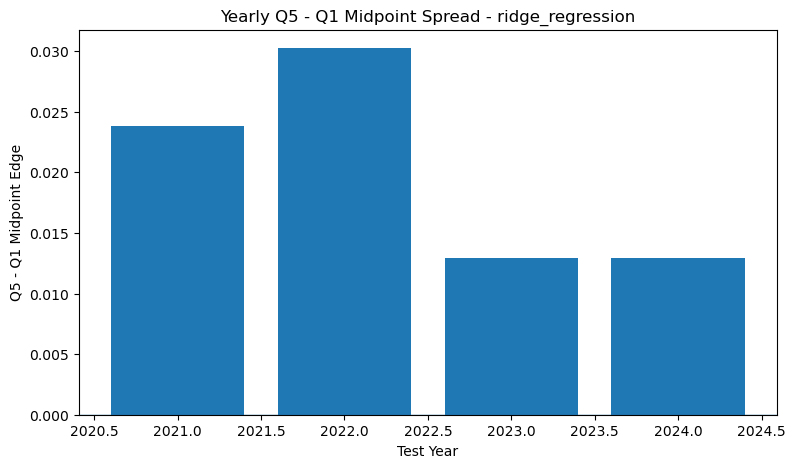

In [16]:
# Plot Q5 - Q1 midpoint spread by year.
#
# Positive means predicted-best group had better midpoint edge than predicted-worst group.

for model_name in sorted(yearly_strategy_spreads["model"].unique()):
    temp = yearly_strategy_spreads[
        yearly_strategy_spreads["model"] == model_name
    ].copy()
    
    plt.figure(figsize=(9, 5))
    plt.bar(temp["test_year"], temp["q5_minus_q1_mid_edge"])
    plt.axhline(0, linewidth=1)
    plt.xlabel("Test Year")
    plt.ylabel("Q5 - Q1 Midpoint Edge")
    plt.title(f"Yearly Q5 - Q1 Midpoint Spread - {model_name}")
    plt.show()

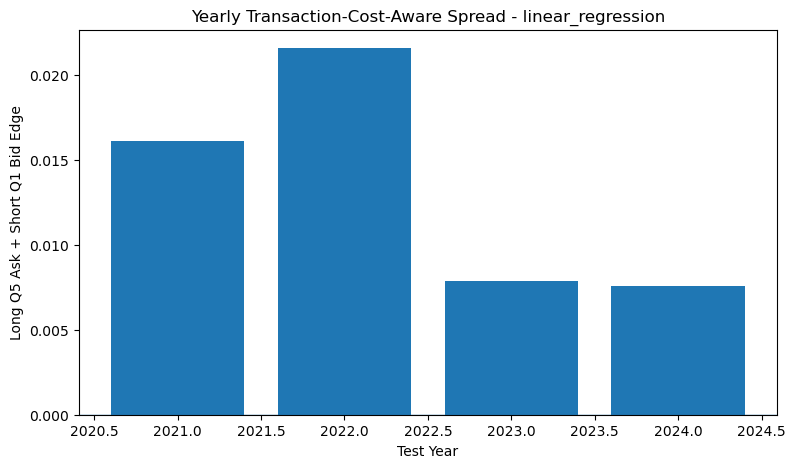

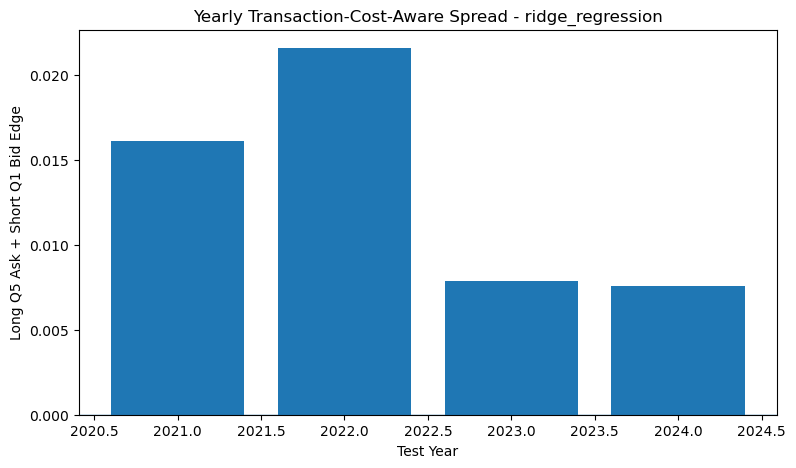

In [17]:
# Plot transaction-cost-aware spread:
#
# Long Q5 at ask + Short Q1 at bid.
#
# This is more conservative than midpoint spread.
#
# Positive means the theoretical long-short spread survives simple bid/ask costs.

for model_name in sorted(yearly_strategy_spreads["model"].unique()):
    temp = yearly_strategy_spreads[
        yearly_strategy_spreads["model"] == model_name
    ].copy()
    
    plt.figure(figsize=(9, 5))
    plt.bar(temp["test_year"], temp["long_q5_ask_short_q1_bid_edge"])
    plt.axhline(0, linewidth=1)
    plt.xlabel("Test Year")
    plt.ylabel("Long Q5 Ask + Short Q1 Bid Edge")
    plt.title(f"Yearly Transaction-Cost-Aware Spread - {model_name}")
    plt.show()

In [18]:
# Compare models using the most important strategy metrics.
#
# We focus on:
#     1. Buy Q5 midpoint edge
#     2. Buy Q5 at ask edge
#     3. Q5-Q1 midpoint spread
#     4. Long Q5 ask / short Q1 bid spread

model_comparison_rows = []

for model_name in sorted(strategy_df["model"].unique()):
    temp = strategy_df[strategy_df["model"] == model_name].copy()
    q1 = temp[temp["quintile"] == 1].copy()
    q5 = temp[temp["quintile"] == 5].copy()
    
    model_comparison_rows.append({
        "model": model_name,
        "n_total_events": len(temp),
        "n_q1": len(q1),
        "n_q5": len(q5),
        "buy_all_mid_edge": temp["mid_edge"].mean(),
        "buy_q5_mid_edge": q5["mid_edge"].mean(),
        "buy_q5_ask_edge": q5["long_ask_edge"].mean(),
        "buy_q1_mid_edge": q1["mid_edge"].mean(),
        "short_q1_bid_edge": q1["short_bid_edge"].mean(),
        "q5_minus_q1_mid_edge": q5["mid_edge"].mean() - q1["mid_edge"].mean(),
        "long_q5_ask_short_q1_bid_edge": q5["long_ask_edge"].mean() + q1["short_bid_edge"].mean(),
        "q5_pct_positive_mid_edge": (q5["mid_edge"] > 0).mean(),
        "q5_pct_positive_ask_edge": (q5["long_ask_edge"] > 0).mean(),
        "q1_pct_positive_short_bid_edge": (q1["short_bid_edge"] > 0).mean()
    })

model_strategy_comparison = pd.DataFrame(model_comparison_rows)

display(model_strategy_comparison)

,model,n_total_events,n_q1,n_q5,buy_all_mid_edge,buy_q5_mid_edge,buy_q5_ask_edge,buy_q1_mid_edge,short_q1_bid_edge,q5_minus_q1_mid_edge,long_q5_ask_short_q1_bid_edge,q5_pct_positive_mid_edge,q5_pct_positive_ask_edge,q1_pct_positive_short_bid_edge
0,linear_regression,5516,1105,1104,-0.0136,-0.004806,-0.006032,-0.024319,0.018946,0.019513,0.012914,0.35779,0.336957,0.718552
1,ridge_regression,5516,1105,1104,-0.0136,-0.004806,-0.006032,-0.024319,0.018946,0.019513,0.012914,0.35779,0.336957,0.718552


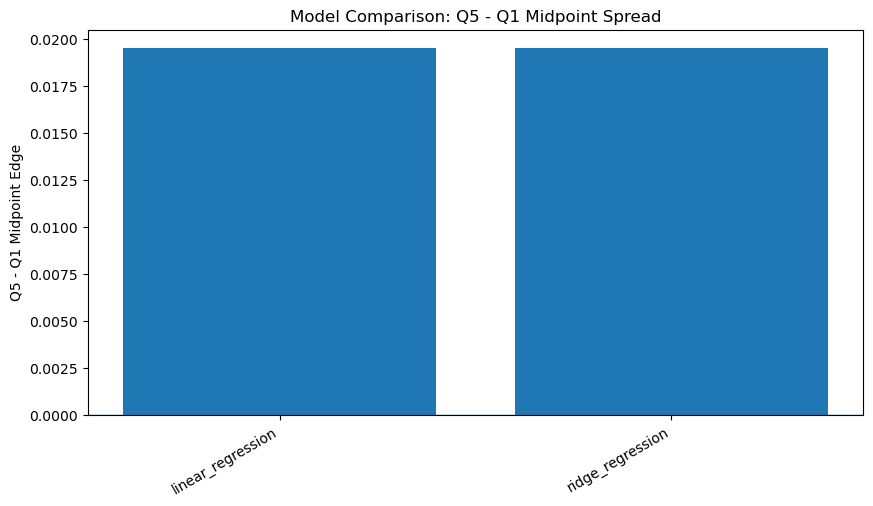

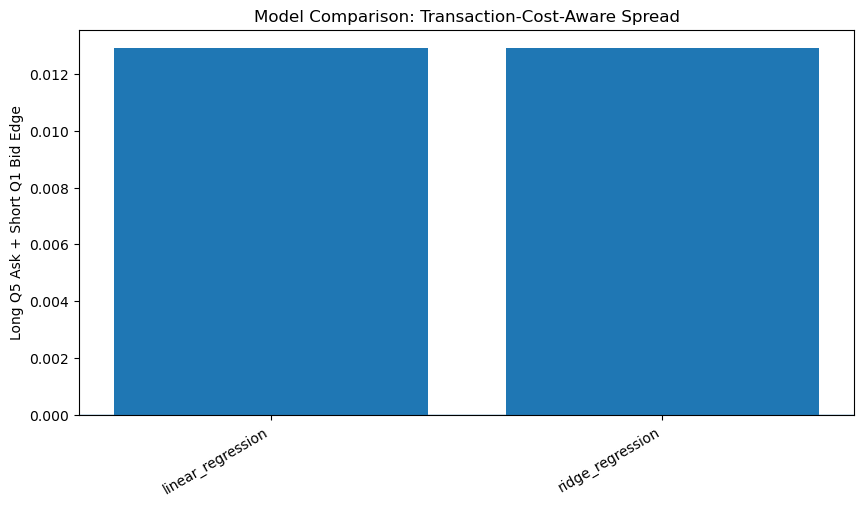

In [19]:
# Plot main model comparison metrics.

plot_df = model_strategy_comparison.copy()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"], plot_df["q5_minus_q1_mid_edge"])
plt.axhline(0, linewidth=1)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Q5 - Q1 Midpoint Edge")
plt.title("Model Comparison: Q5 - Q1 Midpoint Spread")
plt.show()


plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"], plot_df["long_q5_ask_short_q1_bid_edge"])
plt.axhline(0, linewidth=1)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Long Q5 Ask + Short Q1 Bid Edge")
plt.title("Model Comparison: Transaction-Cost-Aware Spread")
plt.show()

In [20]:
# Compare buying all straddles versus buying only the model's predicted-best group.
#
# If buy_q5_mid_edge is less negative than buy_all_mid_edge:
#     the model helps filter to better long-straddle candidates.
#
# If buy_q5_ask_edge is still negative:
#     buying even the best group at ask is not profitable on average.
#
# That would mean the model is better as a filter or relative-value signal
# than as a naive long-only straddle strategy.

buy_filter_comparison = model_strategy_comparison[
    [
        "model",
        "buy_all_mid_edge",
        "buy_q5_mid_edge",
        "buy_q5_ask_edge",
        "q5_pct_positive_mid_edge",
        "q5_pct_positive_ask_edge"
    ]
].copy()

buy_filter_comparison["q5_improvement_vs_all_mid"] = (
    buy_filter_comparison["buy_q5_mid_edge"]
    - buy_filter_comparison["buy_all_mid_edge"]
)

display(buy_filter_comparison)

,model,buy_all_mid_edge,buy_q5_mid_edge,buy_q5_ask_edge,q5_pct_positive_mid_edge,q5_pct_positive_ask_edge,q5_improvement_vs_all_mid
0,linear_regression,-0.0136,-0.004806,-0.006032,0.35779,0.336957,0.008794
1,ridge_regression,-0.0136,-0.004806,-0.006032,0.35779,0.336957,0.008794


In [22]:
# Optional:
# Evaluate top decile instead of top quintile.
#
# A decile splits data into 10 groups.
# D1 = lowest predicted edge
# D10 = highest predicted edge
#
# This avoids groupby().apply() issues by using a simple loop.

decile_parts = []

for (model_name, test_year), group in strategy_df.groupby(["model", "test_year"]):
    g = group.copy()
    
    g["decile"] = pd.qcut(
        g["predicted_edge"].rank(method="first"),
        q=10,
        labels=False
    ) + 1
    
    g["decile"] = g["decile"].astype(int)
    decile_parts.append(g)

decile_df = pd.concat(decile_parts, ignore_index=True)

decile_summary_rows = []

for model_name in sorted(decile_df["model"].unique()):
    temp = decile_df[decile_df["model"] == model_name].copy()
    
    d1 = temp[temp["decile"] == 1]
    d10 = temp[temp["decile"] == 10]
    
    decile_summary_rows.append({
        "model": model_name,
        "d1_mid_edge": d1["mid_edge"].mean(),
        "d10_mid_edge": d10["mid_edge"].mean(),
        "d10_minus_d1_mid_edge": d10["mid_edge"].mean() - d1["mid_edge"].mean(),
        "d10_long_ask_edge": d10["long_ask_edge"].mean(),
        "d1_short_bid_edge": d1["short_bid_edge"].mean(),
        "long_d10_ask_short_d1_bid_edge": d10["long_ask_edge"].mean() + d1["short_bid_edge"].mean(),
        "n_d1": len(d1),
        "n_d10": len(d10)
    })

decile_summary = pd.DataFrame(decile_summary_rows)

display(decile_summary)

,model,d1_mid_edge,d10_mid_edge,d10_minus_d1_mid_edge,d10_long_ask_edge,d1_short_bid_edge,long_d10_ask_short_d1_bid_edge,n_d1,n_d10
0,linear_regression,-0.030763,-0.003288,0.027476,-0.004285,0.024948,0.020663,553,553
1,ridge_regression,-0.030763,-0.003288,0.027476,-0.004285,0.024948,0.020663,553,553


In [23]:
# Save key results.

for f in [strategy_results_file, yearly_strategy_results_file]:
    if os.path.exists(f):
        os.remove(f)

# Combine strategy summaries into one dataframe for saving
strategy_results_to_save = strategy_summary.copy()

con.register("strategy_summary_df", strategy_results_to_save)

con.execute(f"""
COPY strategy_summary_df
TO '{strategy_results_file}'
(FORMAT PARQUET)
""")

con.register("yearly_strategy_spreads_df", yearly_strategy_spreads)

con.execute(f"""
COPY yearly_strategy_spreads_df
TO '{yearly_strategy_results_file}'
(FORMAT PARQUET)
""")

strategy_summary.to_csv(strategy_results_csv, index=False)
yearly_strategy_spreads.to_csv(yearly_strategy_results_csv, index=False)

print("Saved strategy summary to:")
print(strategy_results_file)
print(strategy_results_csv)

print("\nSaved yearly strategy results to:")
print(yearly_strategy_results_file)
print(yearly_strategy_results_csv)

Saved strategy summary to:
data\processed\modeling_part4_strategy_results.parquet
data\processed\modeling_part4_strategy_results.csv

Saved yearly strategy results to:
data\processed\modeling_part4_yearly_strategy_results.parquet
data\processed\modeling_part4_yearly_strategy_results.csv


In [24]:
# Save additional useful summaries.

quintile_perf_csv = os.path.join(PROCESSED_DIR, "modeling_part4_quintile_performance.csv")
model_strategy_comparison_csv = os.path.join(PROCESSED_DIR, "modeling_part4_model_strategy_comparison.csv")
buy_filter_comparison_csv = os.path.join(PROCESSED_DIR, "modeling_part4_buy_filter_comparison.csv")
decile_summary_csv = os.path.join(PROCESSED_DIR, "modeling_part4_decile_summary.csv")

quintile_perf.to_csv(quintile_perf_csv, index=False)
model_strategy_comparison.to_csv(model_strategy_comparison_csv, index=False)
buy_filter_comparison.to_csv(buy_filter_comparison_csv, index=False)
decile_summary.to_csv(decile_summary_csv, index=False)

print("Saved additional CSV files:")
print(quintile_perf_csv)
print(model_strategy_comparison_csv)
print(buy_filter_comparison_csv)
print(decile_summary_csv)

Saved additional CSV files:
data\processed\modeling_part4_quintile_performance.csv
data\processed\modeling_part4_model_strategy_comparison.csv
data\processed\modeling_part4_buy_filter_comparison.csv
data\processed\modeling_part4_decile_summary.csv


In [25]:
# Final interpretation helper.
#
# These are the key tables to inspect after running Part 4.

print("=" * 100)
print("IMPORTANT OUTPUT 1: Overall strategy summary")
print("=" * 100)
display(strategy_summary)

print("""
How to read this:

Buy all straddles - midpoint:
    Baseline result using midpoint prices.

Buy Q5 predicted-best - midpoint:
    What happens if we only buy the model's favorite straddles at midpoint.

Buy Q5 predicted-best - at ask:
    More realistic long-straddle result using ask prices.

Buy Q1 predicted-worst - midpoint:
    What happens if we buy the model's least favorite straddles.

Short Q1 predicted-worst - at bid:
    Simplified short-straddle proxy using bid prices.

Long Q5 / Short Q1 - midpoint spread:
    Relative-value spread using midpoint edges.

Long Q5 at ask / Short Q1 at bid:
    More conservative relative-value spread using bid/ask.
""")

print("=" * 100)
print("IMPORTANT OUTPUT 2: Model strategy comparison")
print("=" * 100)
display(model_strategy_comparison)

print("""
Key things to check:

1. buy_q5_mid_edge > buy_all_mid_edge
    Means the model improves long-straddle selection.

2. buy_q5_ask_edge
    If this is still negative, buying top straddles at ask is not profitable on average.

3. q5_minus_q1_mid_edge > 0
    Means predicted-best straddles outperform predicted-worst straddles.

4. long_q5_ask_short_q1_bid_edge > 0
    Means the long-short spread survives simple bid/ask transaction costs.
""")

print("=" * 100)
print("IMPORTANT OUTPUT 3: Yearly strategy spreads")
print("=" * 100)
display(yearly_strategy_spreads)

print("""
Yearly interpretation:

If q5_minus_q1_mid_edge is positive in most years:
    the model ranking is stable.

If long_q5_ask_short_q1_bid_edge is positive in most years:
    the relative-value result survives simple bid/ask costs.

If results are only positive in one year:
    be careful, it may not be robust.
""")

print("=" * 100)
print("IMPORTANT OUTPUT 4: Top decile test")
print("=" * 100)
display(decile_summary)

print("""
Top decile interpretation:

If D10 has much better edge than D1:
    the strongest predicted opportunities are concentrated in the extreme groups.

If D10 ask edge is still negative:
    even the best long-straddle group may not overcome transaction costs.
""")

IMPORTANT OUTPUT 1: Overall strategy summary


,model,strategy,n_events,avg_edge,median_edge,pct_positive
0,linear_regression,Buy all straddles - midpoint,5516,-0.013600,-0.018729,0.290790
1,linear_regression,Buy all straddles - at ask,5516,-0.016555,-0.021338,0.267585
2,linear_regression,Buy Q5 predicted-best - midpoint,1104,-0.004806,-0.009156,0.357790
3,linear_regression,Buy Q5 predicted-best - at ask,1104,-0.006032,-0.010288,0.336957
4,linear_regression,Buy Q1 predicted-worst - midpoint,1105,-0.024319,-0.036882,0.250679
5,linear_regression,Short Q1 predicted-worst - at bid,1105,0.018946,0.030231,0.718552
6,linear_regression,Long Q5 / Short Q1 - midpoint spread,1104,0.019513,0.027726,NaN
7,linear_regression,Long Q5 at ask / Short Q1 at bid,1104,0.012914,0.019943,NaN
8,ridge_regression,Buy all straddles - midpoint,5516,-0.013600,-0.018729,0.290790
9,ridge_regression,Buy all straddles - at ask,5516,-0.016555,-0.021338,0.267585



How to read this:

Buy all straddles - midpoint:
    Baseline result using midpoint prices.

Buy Q5 predicted-best - midpoint:
    What happens if we only buy the model's favorite straddles at midpoint.

Buy Q5 predicted-best - at ask:
    More realistic long-straddle result using ask prices.

Buy Q1 predicted-worst - midpoint:
    What happens if we buy the model's least favorite straddles.

Short Q1 predicted-worst - at bid:
    Simplified short-straddle proxy using bid prices.

Long Q5 / Short Q1 - midpoint spread:
    Relative-value spread using midpoint edges.

Long Q5 at ask / Short Q1 at bid:
    More conservative relative-value spread using bid/ask.

IMPORTANT OUTPUT 2: Model strategy comparison


,model,n_total_events,n_q1,n_q5,buy_all_mid_edge,buy_q5_mid_edge,buy_q5_ask_edge,buy_q1_mid_edge,short_q1_bid_edge,q5_minus_q1_mid_edge,long_q5_ask_short_q1_bid_edge,q5_pct_positive_mid_edge,q5_pct_positive_ask_edge,q1_pct_positive_short_bid_edge
0,linear_regression,5516,1105,1104,-0.0136,-0.004806,-0.006032,-0.024319,0.018946,0.019513,0.012914,0.35779,0.336957,0.718552
1,ridge_regression,5516,1105,1104,-0.0136,-0.004806,-0.006032,-0.024319,0.018946,0.019513,0.012914,0.35779,0.336957,0.718552



Key things to check:

1. buy_q5_mid_edge > buy_all_mid_edge
    Means the model improves long-straddle selection.

2. buy_q5_ask_edge
    If this is still negative, buying top straddles at ask is not profitable on average.

3. q5_minus_q1_mid_edge > 0
    Means predicted-best straddles outperform predicted-worst straddles.

4. long_q5_ask_short_q1_bid_edge > 0
    Means the long-short spread survives simple bid/ask transaction costs.

IMPORTANT OUTPUT 3: Yearly strategy spreads


,model,test_year,q1_mid_edge,q5_mid_edge,q5_minus_q1_mid_edge,q5_long_ask_edge,q1_short_bid_edge,long_q5_ask_short_q1_bid_edge,n_q1,n_q5
0,linear_regression,2021,-0.028721,-0.004883,0.023838,-0.006019,0.022132,0.016113,251,251
1,linear_regression,2022,-0.036556,-0.006309,0.030247,-0.007981,0.029588,0.021607,262,262
2,linear_regression,2023,-0.015927,-0.003015,0.012913,-0.004018,0.011885,0.007867,286,286
3,linear_regression,2024,-0.018073,-0.005132,0.012942,-0.006255,0.013820,0.007565,306,305
4,ridge_regression,2021,-0.028721,-0.004883,0.023838,-0.006019,0.022132,0.016113,251,251
5,ridge_regression,2022,-0.036556,-0.006309,0.030247,-0.007981,0.029588,0.021607,262,262
6,ridge_regression,2023,-0.015927,-0.003015,0.012913,-0.004018,0.011885,0.007867,286,286
7,ridge_regression,2024,-0.018073,-0.005132,0.012942,-0.006255,0.013820,0.007565,306,305



Yearly interpretation:

If q5_minus_q1_mid_edge is positive in most years:
    the model ranking is stable.

If long_q5_ask_short_q1_bid_edge is positive in most years:
    the relative-value result survives simple bid/ask costs.

If results are only positive in one year:
    be careful, it may not be robust.

IMPORTANT OUTPUT 4: Top decile test


,model,d1_mid_edge,d10_mid_edge,d10_minus_d1_mid_edge,d10_long_ask_edge,d1_short_bid_edge,long_d10_ask_short_d1_bid_edge,n_d1,n_d10
0,linear_regression,-0.030763,-0.003288,0.027476,-0.004285,0.024948,0.020663,553,553
1,ridge_regression,-0.030763,-0.003288,0.027476,-0.004285,0.024948,0.020663,553,553



Top decile interpretation:

If D10 has much better edge than D1:
    the strongest predicted opportunities are concentrated in the extreme groups.

If D10 ask edge is still negative:
    even the best long-straddle group may not overcome transaction costs.

